## Demographic characterization

In [17]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
TABLES.mkdir(exist_ok=True)

df = U.load_anonymized()
imp_long = pd.read_csv(U.DATA_PROC / "likert_importance.csv")
pri_long = pd.read_csv(U.DATA_PROC / "likert_priority.csv")
skills_long = pd.read_csv(U.DATA_PROC / "skills.csv")
words = pd.read_csv(U.DATA_PROC / "words.csv")
print(f"N={len(df)}, importance={len(imp_long)}, priority={len(pri_long)}")

N=56, importance=728, priority=728


In [18]:
def freq_table(series: pd.Series, label: str, order=None) -> pd.DataFrame:
    counts = series.value_counts(dropna=False)
    if order is not None:
        counts = counts.reindex(order).fillna(0).astype(int)
    pct = (counts / counts.sum() * 100).round(1)
    out = pd.DataFrame({"Category": counts.index, "n": counts.values, "%": pct.values})
    out.insert(0, "Variable", "")
    out.iloc[0, 0] = label
    return out

blocks = [
    freq_table(df["gender_norm"], "Gender"),
    freq_table(df["age_band"], "Age band",
               order=["18-24 years", "25-34 years", "35-44 years", "45-54 years", "55-64 years"]),
    freq_table(df["norm_country"], "Country"),
    freq_table(df["education_norm"], "Education"),
    freq_table(df["role_group"], "Role"),
    freq_table(df["seniority_norm"], "Seniority"),
]
demo_table = pd.concat(blocks, ignore_index=True)
demo_table = demo_table[demo_table["n"] > 0].reset_index(drop=True)
demo_table

,Variable,Category,n,%
0,Gender,male,45,80.4
1,,female,11,19.6
2,Country,Brazil,42,75.0
3,,United States,5,8.9
4,,Germany,4,7.1
5,,France,2,3.6
6,,Ireland,1,1.8
7,,Colombia,1,1.8
8,,China,1,1.8
9,Education,Doctoral student,18,32.1


In [19]:
import numpy as np
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ── Palettes (extended so they never run short as N grows) ────────────────────
_TEAL   = ["#0F6E56", "#1D9E75", "#5DCAA5", "#9FE1CB", "#C5F0E3", "#E0F8F2"]
_BLUE   = ["#01579B", "#0277BD", "#00ACC1", "#80DEEA", "#B2EBF2", "#E0F7FA"]
_PURPLE = ["#231A6B", "#3C3489", "#524DB5", "#6B66D0", "#7F77DD", "#9590E6", "#ADAAF0", "#C5C3F7"]
_CORAL  = ["#993C1D", "#D85A30", "#E87A55", "#F0997B", "#F5C4B3", "#FAE0D6", "#FDF0EC", "#FEF8F5"]
_AMBER  = ["#7A3D00", "#B85900", "#E07200", "#F59200", "#F8B030", "#FAC860", "#FCE09A", "#FEF2D5"]
_BG = "#FFFFFF"

# ── Data ─────────────────────────────────────────────────────────────────────
# 1. Age Band — oldest→youngest (top→bottom in funnel)
_age = (df["age_band"].value_counts()
        .reindex(["45-54", "35-44", "25-34", "18-24"])
        .dropna().astype(int))

# 2. Seniority — short labels; Intern at bottom, Senior at top
_SEN_SHORT = {
    "Trainee": "Trainee",
    "Junior (up to 5 years)": "Junior",
    "Full (6 to 9 years)": "Full",
    "Senior (10+ years)": "Senior",
}
_sen = (df["seniority_norm"].map(_SEN_SHORT).value_counts()
        .reindex(list(_SEN_SHORT.values())).dropna().astype(int))

# 3. Country — largest bubble centred, rest in tight ring
_cvc = df["norm_country"].value_counts()
_cdf = pd.DataFrame({"country": _cvc.index, "n": _cvc.values}).sort_values("n", ascending=False).reset_index(drop=True)
_nc  = len(_cdf)
_ang = [2 * np.pi * i / max(_nc - 1, 1) + np.pi / 5 for i in range(_nc - 1)]
_bx  = [0.0] + [0.65 * np.cos(a) for a in _ang]
_by  = [0.0] + [0.4  * np.sin(a) for a in _ang]

if "Germany" in _cdf["country"].values:
    idx_germany = _cdf.index[_cdf["country"] == "Germany"][0]
    _bx[idx_germany] -= 0.3
if "Colombia" in _cdf["country"].values:
    idx_colombia = _cdf.index[_cdf["country"] == "Colombia"][0]
    _bx[idx_colombia] += 0.30
    _by[idx_colombia] -= 0.05

_bsz = (np.sqrt(_cdf["n"]) / np.sqrt(_cdf["n"].max()) * 115 + 54).tolist()

# 4. Role — most frequent on the left
_role = df["role_group"].value_counts().sort_values(ascending=False)

# ── Figure (2×2) ─────────────────────────────────────────────────────────────
fig_demo = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "funnel"}, {"type": "xy"}],
           [{"type": "xy"},     {"type": "xy"}]],
    subplot_titles=["Age Band", "Seniority", "Country", "Role"],
    horizontal_spacing=0.04,
    vertical_spacing=0.08,
)

# 1 — Funnel (row 1, col 1)
fig_demo.add_trace(go.Funnel(
    y=_age.index.tolist(), x=_age.values.tolist(),
    textinfo="value",
    textfont=dict(color="white", size=15, family="sans-serif"),
    marker=dict(color=_TEAL[:len(_age)], line=dict(color="white", width=1.2)),
    connector=dict(line=dict(color="rgba(0,0,0,0)", width=0)),
), row=1, col=1)

# 2 — Horizontal bar (Seniority) — leading spaces create gap between label and bar
fig_demo.add_trace(go.Bar(
    y=["  " + lbl for lbl in _sen.index.tolist()], x=_sen.values.tolist(),
    orientation="h",
    marker=dict(color=_BLUE[:len(_sen)], line=dict(color="white", width=0.8)),
    text=_sen.values.tolist(), textposition="inside",
    insidetextanchor="middle",
    textfont=dict(color="white", size=15),
    width=0.58,
), row=1, col=2)

# 3 — Bubble (Country) (row 2, col 1)
fig_demo.add_trace(go.Scatter(
    x=_bx, y=_by,
    mode="markers+text",
    marker=dict(size=_bsz, color=_PURPLE[:_nc], opacity=0.88,
                line=dict(color="white", width=2.0), sizemode="diameter"),
    text=[f"<b>{c}</b><br>{n}" for c, n in zip(_cdf["country"], _cdf["n"])],
    textposition="middle center",
    textfont=dict(color="white", size=13, family="sans-serif"),
    hovertemplate="%{text}<extra></extra>", cliponaxis=False
), row=2, col=1)

# 4 — Vertical bar (Role) — most frequent on left, counts above bars
fig_demo.add_trace(go.Bar(
    x=_role.index.tolist(), y=_role.values.tolist(),
    marker=dict(color=_AMBER[:len(_role)], line=dict(color="white", width=0.8)),
    text=_role.values.tolist(), textposition="outside",
    textfont=dict(size=13, color="#2C2C2A"),
    width=0.58, cliponaxis=False,
), row=2, col=2)

# ── Styling ───────────────────────────────────────────────────────────────────
fig_demo.update_layout(
    paper_bgcolor=_BG, plot_bgcolor=_BG,
    showlegend=False, width=960, height=580,
    margin=dict(t=65, b=30, l=10, r=10),
    font=dict(family="sans-serif", size=10, color="#2C2C2A"),
)
# Seniority (row 1, col 2)
fig_demo.update_xaxes(showgrid=False, zeroline=False, showticklabels=False,
                      range=[-1.5, int(_sen.max()) + 1], row=1, col=2)
fig_demo.update_yaxes(showgrid=False, zeroline=False,
                      tickfont=dict(size=13), row=1, col=2)
# Country (row 2, col 1)
fig_demo.update_xaxes(showgrid=False, zeroline=False, showticklabels=False,
                      range=[-0.82, 0.82], row=2, col=1)
fig_demo.update_yaxes(showgrid=False, zeroline=False, showticklabels=False,
                      range=[-0.56, 0.56], row=2, col=1)
# Role (row 2, col 2) — vertical bar
fig_demo.update_xaxes(showgrid=False, zeroline=False,
                      tickangle=-35, tickfont=dict(size=12), row=2, col=2)
fig_demo.update_yaxes(showgrid=False, zeroline=False, showticklabels=False, row=2, col=2)

U.save_fig(fig_demo, "demographics")
fig_demo.show()

In [20]:
# # projects: descriptive stats
proj = df["n_projects"]
proj_stats = pd.Series({
    "min": int(proj.min()),
    "Q1": float(proj.quantile(0.25)),
    "median": float(proj.median()),
    "Q3": float(proj.quantile(0.75)),
    "max": int(proj.max()),
    "mean": float(proj.mean()),
})
print("ML projects already participated in:")
print(proj_stats.round(1).to_string())

ML projects already participated in:
min        0.0
Q1         2.0
median     4.0
Q3         7.0
max       40.0
mean       6.4


In [21]:
df["n_projects"].value_counts()

n_projects
3     10
2      9
5      6
6      5
4      5
1      4
10     3
8      3
0      2
40     2
15     2
7      2
13     1
11     1
25     1
Name: count, dtype: int64

In [22]:
bins = [0, 3, 6, 12, 15, float("inf")]
labels = [
    "less than 3",
    "between 3 and 6",
    "between 7 and 12",
    "between 12 and 15",
    "more than 15"
]

faixas = pd.cut(
    df["n_projects"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

contagem = faixas.value_counts().reindex(labels, fill_value=0)

for faixa, qtd in contagem.items():
    print(f"{faixa}: {qtd}")

less than 3: 25
between 3 and 6: 16
between 7 and 12: 9
between 12 and 15: 3
more than 15: 3


In [23]:
# Saves LaTeX table that will go in as Table 2 in the paper
def df_to_latex_demo(df: pd.DataFrame) -> str:
    lines = [
        "\\begin{table}[t]",
        "\\caption{Respondent characterization ($n=32$).}",
        "\\label{tab:demographics}",
        "\\centering",
        "\\small",
        "\\begin{tabular}{lp{4.5cm}rr}",
        "\\toprule",
        "\\textbf{Variable} & \\textbf{Category} & \\textbf{n} & \\textbf{\\%} \\\\",
        "\\midrule",
    ]
    for _, row in df.iterrows():
        var = row["Variable"] if row["Variable"] else ""
        cat = str(row["Category"]).replace("_", "\\_")
        lines.append(f"{var} & {cat} & {row['n']} & {row['%']:.1f} \\\\")
    lines.extend(["\\bottomrule", "\\end{tabular}", "\\end{table}"])
    return "\n".join(lines)

(TABLES / "demographics.tex").write_text(df_to_latex_demo(demo_table))
print("[saved] tables/demographics.tex")

[saved] tables/demographics.tex


## 7. Frequencies (Q19 discussion + Q22 support)

Two distributions in 1 figure sharing aesthetics.

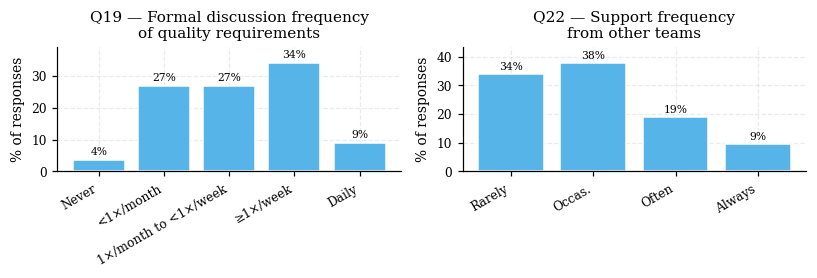

In [24]:
disc_labels = ["Never", "<1×/month", "1×/month to <1×/week", "≥1×/week", "Daily"]
supp_labels = ["Rarely", "Occas.", "Often", "Always"]

fig, axes = plt.subplots(1, 2, figsize=(7.5, 2.6))

for ax, col, labels, title in [
    (axes[0], "discussion_freq", disc_labels,
     "Q19 — Formal discussion frequency\nof quality requirements"),
    (axes[1], "support_freq", supp_labels,
     "Q22 — Support frequency\nfrom other teams"),
]:
    counts = df[col].value_counts(dropna=False).reindex(range(1, len(labels) + 1), fill_value=0)
    pct = counts / counts.sum() * 100
    ax.bar(range(len(labels)), pct.values, color=U.PALETTE_WONG[2], edgecolor="white")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("% of responses")
    ax.set_title(title)
    ax.set_ylim(0, max(pct.values) * 1.15)
    for i, v in enumerate(pct.values):
        ax.text(i, v + 1, f"{v:.0f}%", ha="center", va="bottom", fontsize=7)

fig.tight_layout()
U.save_fig(fig, "frequencies")
plt.show()

## 10. Heatmap subgroups × characteristics (% top-2)

Rows = subgroup, columns = characteristic, value = % "Important/Very important". Quickly highlights visual differences (Diversity Matters style).

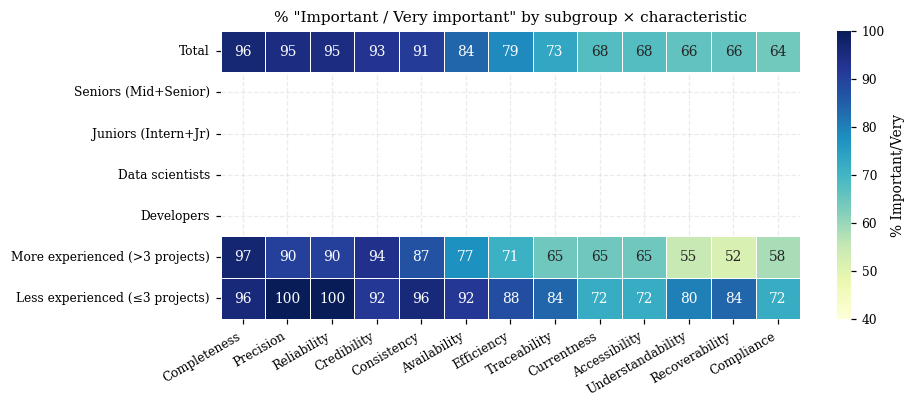

In [25]:
def pct_top2(df_sub: pd.DataFrame, col: str) -> float:
    s = df_sub[col].dropna()
    if len(s) == 0:
        return float("nan")
    return (s >= 4).sum() / len(s) * 100

groups = {
    "Total": df,
    "Seniors (Mid+Senior)": df[df["seniority_group"] == "senior"],
    "Juniors (Intern+Jr)": df[df["seniority_group"] == "junior"],
    "Data scientists": df[df["role_group"] == "data_scientist"],
    "Developers": df[df["role_group"] == "developer"],
    "More experienced (>3 projects)": df[df["n_projects"] > 3],
    "Less experienced (≤3 projects)": df[df["n_projects"] <= 3],
}

heat = pd.DataFrame(
    {label: [pct_top2(g, f"imp_{c}") for c in U.CHARACTERISTICS_PT.keys()] for label, g in groups.items()},
    index=[U.CHARACTERISTICS_PT[c] for c in U.CHARACTERISTICS_PT.keys()],
).T
# Sort columns by total %
heat = heat[heat.loc["Total"].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8.5, 3.4))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "% Important/Very"},
            linewidths=0.4, linecolor="white", ax=ax, vmin=40, vmax=100)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("% \"Important / Very important\" by subgroup × characteristic")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
U.save_fig(fig, "heatmap_importance_subgroups")
plt.show()

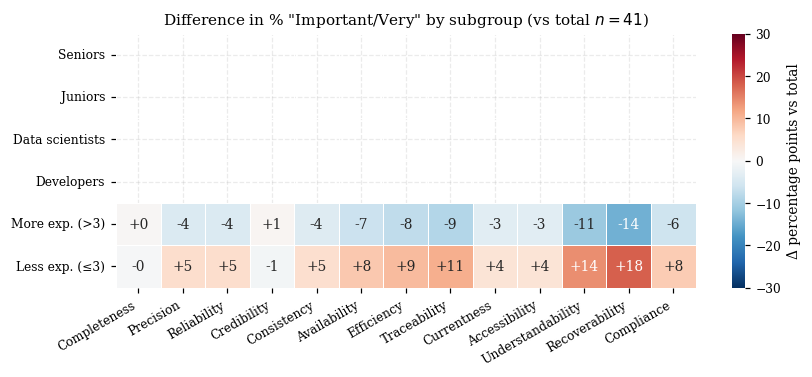

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
U.setup_matplotlib()

def pct_top2(g, col):
    s = g[col].dropna()
    return (s >= 4).sum() / len(s) * 100 if len(s) else np.nan

groups_def = {
    "Seniors": df[df["seniority_group"] == "senior"],
    "Juniors": df[df["seniority_group"] == "junior"],
    "Data scientists": df[df["role_group"] == "data_scientist"],
    "Developers": df[df["role_group"] == "developer"],
    "More exp. (>3)": df[df["n_projects"] > 3],
    "Less exp. (≤3)": df[df["n_projects"] <= 3],
}
total_imp = pd.Series({c: pct_top2(df, f"imp_{c}") for c in U.CHARACTERISTICS_PT.keys()})
diffs = pd.DataFrame({
    label: [pct_top2(g, f"imp_{c}") - total_imp[c] for c in U.CHARACTERISTICS_PT.keys()]
    for label, g in groups_def.items()
}, index=[U.CHARACTERISTICS_PT[c] for c in U.CHARACTERISTICS_PT.keys()]).T
diffs = diffs[total_imp.sort_values(ascending=False).rename(lambda c: U.CHARACTERISTICS_PT[c]).index]

fig, ax = plt.subplots(figsize=(8.5, 3.0))
sns.heatmap(diffs, annot=True, fmt="+.0f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Δ percentage points vs total"},
            linewidths=0.4, linecolor="white", ax=ax, vmin=-30, vmax=30)
ax.set_title("Difference in % \"Important/Very\" by subgroup (vs total $n=41$)")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
U.save_fig(fig, "heatmap_subgroup_diff")
plt.show()

## 13. Internal reliability — Cronbach α and McDonald ω

Before treating Q11/Q13 as aggregated "constructs" (e.g., "% High Importance"),
we measure internal consistency of the blocks as Likert scales.

- **Cronbach α**: assumes tau-equivalence; pingouin returns a bootstrap 95% CI.
- **McDonald ω total**: 1-factor analysis on standardized items (`U.mcdonald_omega`); less sensitive to tau-equivalence violations.

Convention: α ≥ 0.7 acceptable, ≥ 0.8 good, ≥ 0.9 excellent (Nunnally 1978).


In [27]:
import pingouin as pg

def reliability_block(name: str, items: pd.DataFrame) -> dict:
    items = items.dropna()
    alpha, ci = pg.cronbach_alpha(data=items)
    omega = U.mcdonald_omega(items)
    return {"block": name, "n_subj": len(items), "k_items": items.shape[1],
            "cronbach_alpha": float(alpha),
            "alpha_ci_lo": float(ci[0]), "alpha_ci_hi": float(ci[1]),
            "mcdonald_omega": omega}

reli_imp = reliability_block("Q11 importance", df[U.IMP_COLS])
reli_pri = reliability_block("Q13 priority", df[U.PRI_COLS])
reli_skill = reliability_block("Q8 skills", df[U.SKILL_COLS])

reliability = pd.DataFrame([reli_imp, reli_pri, reli_skill])
print(reliability.to_string(index=False))
print()
for r in [reli_imp, reli_pri, reli_skill]:
    interp = (
        "excellent" if r["cronbach_alpha"] >= 0.9 else
        "good" if r["cronbach_alpha"] >= 0.8 else
        "acceptable" if r["cronbach_alpha"] >= 0.7 else
        "questionable" if r["cronbach_alpha"] >= 0.6 else
        "inadequate"
    )
    print(f"{r['block']}: α={r['cronbach_alpha']:.3f} "
          f"[{r['alpha_ci_lo']:.3f}, {r['alpha_ci_hi']:.3f}], "
          f"ω={r['mcdonald_omega']:.3f} — {interp} reliability.")


         block  n_subj  k_items  cronbach_alpha  alpha_ci_lo  alpha_ci_hi  mcdonald_omega
Q11 importance      56       13        0.905140        0.864        0.938        0.908007
  Q13 priority      56       13        0.892174        0.846        0.930        0.894550
     Q8 skills      49       10        0.919073        0.881        0.949        0.921662

Q11 importance: α=0.905 [0.864, 0.938], ω=0.908 — excellent reliability.
Q13 priority: α=0.892 [0.846, 0.930], ω=0.895 — good reliability.
Q8 skills: α=0.919 [0.881, 0.949], ω=0.922 — excellent reliability.


In [28]:
reliability.to_csv(TABLES / "reliability.csv", index=False)
print(f"-> tables/reliability.csv")


-> tables/reliability.csv


In [29]:
pd.set_option('display.max_columns', None)
df.head()

,language,timestamp,state,n_projects,skill_cleaning,skill_normalization,skill_outliers,skill_integration,skill_transformation,skill_validation,skill_pipelines,skill_monitoring,skill_libs,skill_split,word_1,word_2,word_3,word_4,word_5,re_experience,imp_precision,imp_completeness,imp_consistency,imp_credibility,imp_currentness,imp_accessibility,imp_compliance,imp_reliability,imp_efficiency,imp_traceability,imp_understandability,imp_availability,imp_recoverability,imp_justification,pri_precision,pri_completeness,pri_consistency,pri_credibility,pri_currentness,pri_accessibility,pri_compliance,pri_reliability,pri_efficiency,pri_traceability,pri_understandability,pri_availability,pri_recoverability,pri_justification,balance_open,incorporation_open,measurement_open,discussion_freq,documentation_open,challenges_open,support_freq,country,region,norm_country,seniority_norm,role_group,gender_norm,age_band,education_norm,versioning_norm,seniority_ordinal,seniority_group
0,pt,2025-02-14 15:15:25,CE,2,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,precisão,consistência,completude,relevância,viés,"Sim, foi uma ótima experiência, embora complic...",4,4,4,4,4,4,4,4,4,4,4,4,4,NaN,4,4,4,4,4,4,4,4,4,4,4,4,4,NaN,"Equilibrar precisão, compreensibilidade e efic...",Avaliação inicial durante a coleta e preparaçã...,Análise de métricas de performance (ex.: preci...,3,"Linguagem estruturada (texto), Ferramentas de ...",Inconsistência entre diferentes fontes de dado...,2.0,Brazil,Northeast,Brazil,Junior (up to 5 years),Data Scientist,male,18-24,Undergraduate,ensures_consistency_traceability,2,Junior (up to 5 years)
1,pt,2025-02-14 15:46:32,PE,2,5.0,5.0,5.0,3.0,4.0,4.0,3.0,3.0,4.0,5.0,fonte,estabilidade,necessário,essencial,determinante,Não,5,4,5,5,5,5,5,5,5,4,5,5,5,NaN,5,4,5,5,5,5,5,5,5,4,5,5,4,NaN,"A prioridade é na precisão dos dados, seguido ...",Avaliação inicial durante a coleta e preparaçã...,Análise de métricas de performance (ex.: preci...,4,"Linguagem estruturada (texto), Reuniões de Ali...","Dados incompletos ou ausentes, Dados desatuali...",2.0,Brazil,Northeast,Brazil,Junior (up to 5 years),Data Scientist,female,25-34,Doctoral student,ensures_consistency_traceability,2,Junior (up to 5 years)
2,pt,2025-02-14 15:53:04,CE,13,5.0,5.0,5.0,4.0,5.0,5.0,3.0,3.0,4.0,5.0,confiabilidade,disponibilidade,atualização,integridade,processamento,"Geralmente, são os primeiros passos quando co...",5,5,5,5,5,5,5,5,5,5,5,5,5,NaN,4,4,4,5,5,5,5,5,3,4,4,4,4,NaN,Tudo vai depender de como nossa aplicação prec...,Avaliação inicial durante a coleta e preparaçã...,Análise de métricas de performance (ex.: preci...,3,"Linguagem estruturada (texto), Ferramentas de ...",Inconsistência entre diferentes fontes de dado...,4.0,Brazil,Northeast,Brazil,Full (6 to 9 years),Data Scientist,male,25-34,Master,ensures_consistency_traceability,3,Full (6 to 9 years)
3,pt,2025-02-14 17:01:56,CE,6,4.0,4.0,4.0,4.0,4.0,5.0,3.0,4.0,4.0,5.0,ruído,sinal,teste,informação,validação,Trabalho em um projeto a dois anos onde desenv...,5,4,5,5,4,4,4,5,4,4,4,4,4,NaN,5,4,5,5,3,3,2,4,4,3,2,3,3,NaN,NaN,Avaliação inicial durante a coleta e preparaçã...,Análise de métricas de performance (ex.: preci...,4,Documentação Centralizada (Sistemas como Confl...,"Dados incompletos ou ausentes, Falta de padron...",2.0,Brazil,Northeast,Brazil,Full (6 to 9 years),Data Scientist,male,25-34,Doctoral student,ensures_consistency_traceability,3,Full (6 to 9 years)
4,pt,2025-02-14 18:42:17,CE,5,5.0,4.0,3.0,3.0,3.0,3.0,2.0,2.0,4.0,5.0,precisão,consistência,completude,relevância,atualização,Já participei de todas as fases do ciclo de um...,5,5,5,5,2,3,3,4,4,3,3,3,3,NaN,5,5,5,3,3,3,3,4,3,3,3,3,3,NaN,"Equilibrar precisão, compreensibilidade e efic...",Avaliação inicial durante a coleta e preparaçã...,Análise de métricas de performance (ex.: preci...,3,"Linguagem estruturada (texto), Reuniões de Ali...",Inconsistência entre diferentes fontes de dado...,1.0,Brazil,Northeast,Brazil,Senior (10+ years),Data Scientist,male,25-34,Doctoral stud

In [30]:
df['n_projects'].shape

(56,)

## Q8 — Self-assessed skill level in data processing activities

In [ ]:
def _bootstrap_ci(
    long_df: pd.DataFrame,
    item_col: str,
    value_col: str,
    items: list,
    top_levels: list[int],
    bottom_levels: list[int],
    n_bootstrap: int = 1000,
    ci_level: float = 0.95,
    random_state: int | None = 42,
) -> pd.DataFrame:

    rng = np.random.default_rng(random_state)
    alpha = 1 - ci_level
    rows = {}

    for key in items:
        s = long_df.loc[long_df[item_col] == key, value_col].dropna()
        n = len(s)

        if n == 0:
            rows[key] = {
                "pct_top2": float("nan"), "ci_lo": float("nan"), "ci_hi": float("nan"),
                "pct_bottom2": float("nan"), "ci_bottom_lo": float("nan"), "ci_bottom_hi": float("nan")
            }
            continue

        vals = s.values
        pct_top2    = s.isin(top_levels).mean()    * 100
        pct_bottom2 = s.isin(bottom_levels).mean() * 100

        boot_indices = rng.integers(0, n, size=(n_bootstrap, n))
        boot_props_top    = np.isin(vals[boot_indices], top_levels).mean(axis=1)    * 100
        boot_props_bottom = np.isin(vals[boot_indices], bottom_levels).mean(axis=1) * 100

        rows[key] = {
            "pct_top2":     pct_top2,
            "ci_lo":        np.percentile(boot_props_top,    100 * alpha / 2),
            "ci_hi":        np.percentile(boot_props_top,    100 * (1 - alpha / 2)),
            "pct_bottom2":  pct_bottom2,
            "ci_bottom_lo": np.percentile(boot_props_bottom, 100 * alpha / 2),
            "ci_bottom_hi": np.percentile(boot_props_bottom, 100 * (1 - alpha / 2)),
        }

    return pd.DataFrame(rows).T


# Neutral uses #D9D9D9 (visible mid-gray); U.PALETTE_LIKERT_5[2] is near-white (#f7f7f7)
_PALETTE_LIKERT_5 = ["#3B1F6E", "#9B72CF", "#D9D9D9", "#7BC67E", "#1A6B3C"]


def diverging_stacked(
    long_df: pd.DataFrame,
    item_col: str,
    value_col: str,
    item_labels: dict[str, str],
    level_labels: list[str],
    figsize: tuple[float, float] = (7.0, 4.5),
    palette: list[str] | None = None,
    sort_by_positive: bool = True,
    ci_df: pd.DataFrame | None = None,
) -> plt.Figure:

    n_levels = len(level_labels)
    if palette is None:
        palette = _PALETTE_LIKERT_5 if n_levels == 5 else [f"C{i}" for i in range(n_levels)]

    items = list(item_labels.keys())

    counts = (
        long_df.groupby(item_col)[value_col]
        .value_counts().unstack(fill_value=0)
        .reindex(index=items, columns=range(1, n_levels + 1), fill_value=0)
    )
    pct = counts.div(counts.sum(axis=1), axis=0) * 100

    if sort_by_positive:
        positive = pct[[n_levels - 1, n_levels]] if n_levels >= 4 else pct[[n_levels]]
        order    = positive.sum(axis=1).sort_values().index
        pct      = pct.loc[order]
        counts   = counts.loc[order]
        items    = list(order)

    if n_levels == 5:
        neg_levels, neutral, pos_levels = [1, 2], 3, [4, 5]
    elif n_levels == 4:
        neg_levels, neutral, pos_levels = [1, 2], None, [3, 4]
    else:
        raise ValueError("diverging_stacked expects 4 or 5 levels")

    fig, ax = plt.subplots(figsize=figsize)
    y          = np.arange(len(items))
    bar_height = 0.76

    neutral_half = (pct[neutral].values / 2) if neutral is not None else np.zeros(len(items))
    cur = -(neutral_half + pct[neg_levels[1]].values + pct[neg_levels[0]].values)

    # negative bars
    for lvl, color in zip(neg_levels, palette[:len(neg_levels)]):
        widths = pct[lvl].values
        ax.barh(y, widths, left=cur, height=bar_height,
                color=color, edgecolor="white", linewidth=0.4,
                label=level_labels[lvl - 1])
        for i, w in enumerate(widths):
            if w >= 4:
                ax.text(cur[i] + w / 2, y[i], f"{w:.0f}%",
                        ha="center", va="center", fontsize=9,
                        color="white", fontweight="bold")
        cur += widths

    # neutral bar
    if neutral is not None:
        widths = pct[neutral].values
        ax.barh(y, widths, left=-widths / 2, height=bar_height,
                color=palette[neutral - 1], edgecolor="white", linewidth=0.4,
                label=level_labels[neutral - 1])
        for i, w in enumerate(widths):
            if w >= 4:
                ax.text(-widths[i] / 2 + w / 2, y[i], f"{w:.0f}%",
                        ha="center", va="center", fontsize=9, color="#333333")

    # positive bars
    cur = neutral_half.copy()
    for lvl, color in zip(pos_levels, palette[-len(pos_levels):]):
        widths = pct[lvl].values
        ax.barh(y, widths, left=cur, height=bar_height,
                color=color, edgecolor="white", linewidth=0.4,
                label=level_labels[lvl - 1])
        for i, w in enumerate(widths):
            if w >= 4:
                ax.text(cur[i] + w / 2, y[i], f"{w:.0f}%",
                        ha="center", va="center", fontsize=9,
                        color="white", fontweight="bold")
        cur += widths

    # CI shadow band
    if ci_df is not None:
        ci_al  = ci_df.reindex(items)
        band_h = bar_height * 0.55
        if "pct_top2" in ci_al.columns:
            x_lo = neutral_half + ci_al["ci_lo"].values
            x_hi = neutral_half + ci_al["ci_hi"].values
            ax.barh(y, x_hi - x_lo, left=x_lo, height=band_h,
                    color="#888888", alpha=0.30, zorder=5, label="95% CI")
        if "pct_bottom2" in ci_al.columns:
            x_lo = -(neutral_half + ci_al["ci_bottom_hi"].values)
            x_hi = -(neutral_half + ci_al["ci_bottom_lo"].values)
            ax.barh(y, x_hi - x_lo, left=x_lo, height=band_h,
                    color="#888888", alpha=0.30, zorder=5)

    ax.axvline(0, color="#333333", linewidth=0.7, zorder=4, linestyle="--", alpha=0.4)

    ax.set_yticks(y)
    ax.set_yticklabels([item_labels[k] for k in items], fontsize=10.5)
    ax.set_xlabel("% of responses", fontsize=10.5)

    ax.set_xlim(-75, 100)
    ax.set_xticks([-75, -50, -25, 0, 25, 50, 75, 100])
    ax.set_xticklabels(["75%", "50%", "25%", "0", "25%", "50%", "75%", "100%"], fontsize=9.5)
    ax.tick_params(axis="x", length=3)

    ax.grid(axis="x", color="#e0e0e0", linewidth=0.5, zorder=0)
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#cccccc")

    handles, labels_leg = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels_leg):
        if l not in seen:
            seen[l] = h
    ax.legend(list(seen.values()), list(seen.keys()),
              loc="upper center", bbox_to_anchor=(0.5, -0.13),
              ncol=len(seen), frameon=False, fontsize=9.5,
              handlelength=1.3, handleheight=0.85,
              borderpad=0, columnspacing=0.9)

    return fig

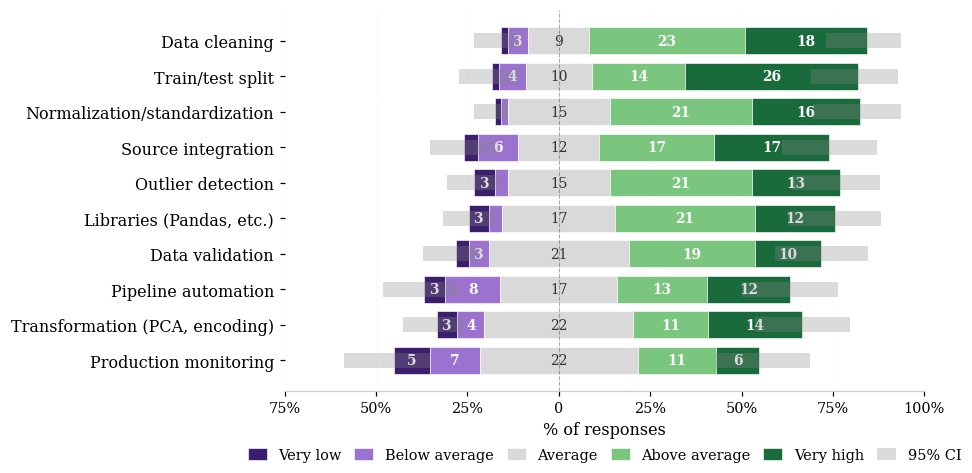

In [32]:
skills_renamed = skills_long.copy()
_skill_items = list(U.SKILL_LABELS_EN.keys())

_skill_ci = _bootstrap_ci(
    skills_renamed.dropna(),
    "activity",
    "skill",
    _skill_items,
    top_levels=[4, 5],
    bottom_levels=[1, 2],
)

fig = diverging_stacked(
    skills_renamed.dropna(),
    item_col="activity",
    value_col="skill",
    item_labels=U.SKILL_LABELS_EN,
    level_labels=["Very low", "Below average", "Average", "Above average", "Very high"],
    figsize=(7.5, 4.5),
    ci_df=_skill_ci,
)

U.save_fig(fig, "skills_diverging")
plt.show()
